# TUs simulation safety parameter plots

In [1]:
import utils
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
# Make output folder
plot_dir = os.path.join('..','plots','acoustic_simulations', 'planning')
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

### Find all csv's from the stimulation output folder

In [3]:
simulation_directory = f'/Volumes/project/3025011.02/TUS_simulations/planning/'

stimulation_output_full_filenames_1 = os.path.join(simulation_directory, '**', '*layered_output_table_target_1*.csv')
stimulation_output_full_filenames_2 = os.path.join(simulation_directory, '**', '*layered_output_table_target_2*.csv')

stimulation_output_full_filenames = glob.glob(stimulation_output_full_filenames_1, recursive=True) + glob.glob(stimulation_output_full_filenames_2, recursive=True)
print(stimulation_output_full_filenames)

['/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-005/sub-005_layered_output_table_target_1_1_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-005/sub-005_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-022/sub-022_layered_output_table_target_1_1_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-022/sub-022_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-037/sub-037_layered_output_table_target_1_1_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-037/sub-037_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-010/sub-010_layered_output_table_target_1_1_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/

### Save them in one dataframe
And add columns with the individual subject_id's, targets etc

In [4]:
# List to hold individual dataframes
list_of_dataframes = []

# Process each CSV file
for stimulation_output_full_filename in stimulation_output_full_filenames:
    # Extract the filename (without the path)
    stimulation_output_filename = os.path.basename(stimulation_output_full_filename)
    # Remove the '.csv' extension
    stimulation_output_filename_without_extension = os.path.splitext(stimulation_output_filename)[0]
    
    # Split the filename by underscores
    stimulation_output_filename_parts = stimulation_output_filename_without_extension.split('_')
    
    # Extract the desired parts from the filename:
    subject_id = stimulation_output_filename_parts[0]                     # e.g. 'sub-010'
    target = '_'.join(stimulation_output_filename_parts[4:7])               # e.g. 'target_2_2'
    duty_cycle = stimulation_output_filename_parts[7]                       # e.g. 'dc1'
    intensity = '_'.join(stimulation_output_filename_parts[8:10])           # e.g. 'strength_1'
    
    # Read the CSV file (assuming it contains one row)
    try:
        df = pd.read_csv(stimulation_output_full_filename)
    except Exception as e:
        print(f"Error reading {stimulation_output_full_filename}: {e}")
        continue  # Skip this file if there's an error

    # Add the extracted metadata as new columns
    df['target'] = target
    df['intensity'] = intensity
    df['duty_cycle'] = duty_cycle
    
    # Append the dataframe to our list
    list_of_dataframes.append(df)

# Combine all dataframes into one
if list_of_dataframes:
    stimulation_output = pd.concat(list_of_dataframes, ignore_index=True)
    print(stimulation_output)
else:
    raise Exception("No CSV files were found or processed.")

     subject_id  max_Isppa  max_Isppa_after_exit_plane  real_focal_distance  \
0             5  23.530720                   23.530720            27.004629   
1             5  46.630840                   46.630840            27.004629   
2            22  13.099920                   13.099920            28.310775   
3            22  25.232270                   25.232270            24.510202   
4            37  13.151360                   13.151360            26.930466   
..          ...        ...                         ...                  ...   
118          28  23.827840                   23.827840            13.509256   
119          29  25.126100                   25.126100            14.008926   
120          38  27.083420                   12.764720             5.000000   
121          40   7.289176                    6.143037             7.582875   
122          44  20.156840                   20.156840            13.000000   

     max_Isppa_skin  max_Isppa_skull  max_Isppa_bra

### Reorder the dataframe and replace strings

In [5]:
# Reorder columns
column_indices = list(range(stimulation_output.shape[1]))
reordered_column_indices = [column_indices[0]] + column_indices[-3:] + column_indices[1:-3]
stimulation_output = stimulation_output.iloc[:, reordered_column_indices]
stimulation_output.sort_values(by=['subject_id', 'target', 'intensity', 'duty_cycle'], inplace=True)
stimulation_output.reset_index(drop=True, inplace=True)

# Replace values to improve readability
stimulation_output['duty_cycle'] = stimulation_output['duty_cycle'].map({'dc10': '10%', 'dc15': '15%', 'dc20': '20%'})
stimulation_output['intensity'] = stimulation_output['intensity'].map({'strength_1': '35', 'strength_2': '63', 'strength_3': '81', 'strength_4': '110'})

# Now drop some columns
stimulation_output.drop(
    ['real_focal_distance','Ix_brain', 'Iy_brain','Iz_brain',
     'focus_pos_final_1', 'focus_pos_final_2', 'focus_pos_final_3',
     'trans_pos_final_1', 'trans_pos_final_2', 'trans_pos_final_3'],
    axis=1,
    inplace=True
)

print(stimulation_output)

     subject_id      target intensity duty_cycle  max_Isppa  \
0             5  target_1_1        35        20%   23.53072   
1             5  target_1_1        63        20%   46.63084   
2             5  target_1_2        35        20%   21.31879   
3             5  target_1_2        63        20%   44.12692   
4             5  target_2_1        81        20%   20.97227   
..          ...         ...       ...        ...        ...   
118          44  target_2_2        81        20%   23.89943   
119          44  target_2_3        81        20%   21.22227   
120          44  target_2_4        81        20%   20.15684   
121          44  target_2_5        81        20%   22.04985   
122          44  target_2_6        81        20%   23.80134   

     max_Isppa_after_exit_plane  max_Isppa_skin  max_Isppa_skull  \
0                      23.53072        23.53072         6.133431   
1                      46.63084        46.63084        12.368000   
2                      21.31879        

# Mechanical index
1.9 is the safety limit
Group by target and intensity

In [6]:
safety_limit = 1.9

### Skin

   subject_id      target        35        63
0           5  target_1_1  1.659198  2.335701
1           5  target_1_2  1.579290  2.272126
2          10  target_1_1  1.118794       NaN
3          14  target_1_1  1.333933       NaN
4          22  target_1_1  1.237984  1.718140
5          22  target_1_2  1.360544       NaN
6          37  target_1_1  1.240412  1.591624
7          37  target_1_2  1.262041       NaN
8          37  target_1_3  1.240412       NaN


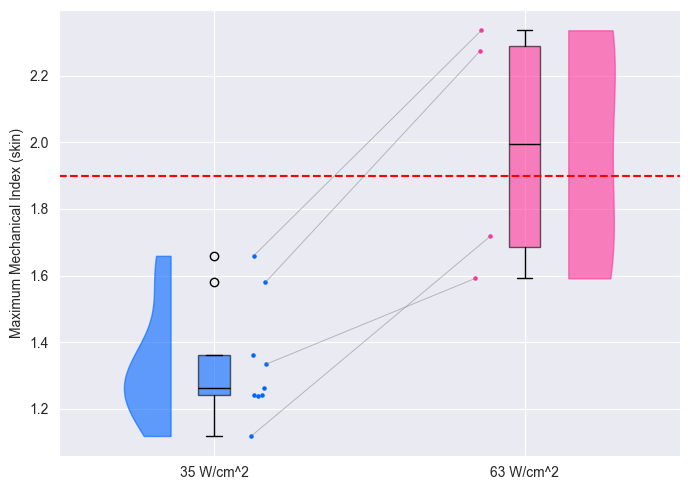

In [7]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_1_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='max_MI_skin',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='35',
        column_2='63',
        labels=['35 W/cm^2', '63 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum Mechanical Index (skin)',
        plot_name='Maximum MI in skin for amygdala stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

In [8]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_2_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='max_MI_skin',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='63',
        column_2='81',
        labels=['63 W/cm^2', '81 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum Mechanical Index (skin)',
        plot_name='Maximum MI in skin for dACC stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

    subject_id      target  35        81
0            5  target_2_1 NaN  1.496021
1            5  target_2_2 NaN  1.428994
2            5  target_2_3 NaN  1.413054
3            5  target_2_4 NaN  1.407157
4            5  target_2_5 NaN  1.555427
..         ...         ...  ..       ...
87          44  target_2_2 NaN  1.672146
88          44  target_2_3 NaN  1.575711
89          44  target_2_4 NaN  1.535648
90          44  target_2_5 NaN  1.606140
91          44  target_2_6 NaN  1.668711

[92 rows x 4 columns]
Skipping block due to error: '63'


### Brain

   subject_id      target        35        63
0           5  target_1_1  0.969362  1.245114
1           5  target_1_2  0.828687  1.090051
2          10  target_1_1  1.029579       NaN
3          14  target_1_1  1.052594       NaN
4          22  target_1_1  0.908005  1.173840
5          22  target_1_2  0.728049       NaN
6          37  target_1_1  1.082360  1.393695
7          37  target_1_2  1.038525       NaN
8          37  target_1_3  1.082360       NaN


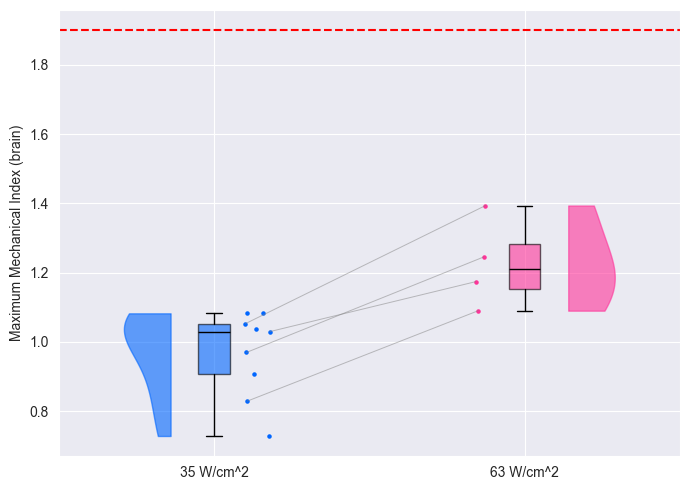

In [9]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_1_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='max_MI_brain',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='35',
        column_2='63',
        labels=['35 W/cm^2', '63 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum Mechanical Index (brain)',
        plot_name='Maximum MI in brain for amygdala stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

In [10]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_2_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='max_MI_brain',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='63',
        column_2='81',
        labels=['63 W/cm^2', '81 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum Mechanical Index (brain)',
        plot_name='Maximum MI in brain for dACC stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

    subject_id      target  35        81
0            5  target_2_1 NaN  0.828914
1            5  target_2_2 NaN  0.905166
2            5  target_2_3 NaN  0.763167
3            5  target_2_4 NaN  0.859165
4            5  target_2_5 NaN  0.825211
..         ...         ...  ..       ...
87          44  target_2_2 NaN  0.867562
88          44  target_2_3 NaN  0.703633
89          44  target_2_4 NaN  0.851232
90          44  target_2_5 NaN  0.699298
91          44  target_2_6 NaN  0.808866

[92 rows x 4 columns]
Skipping block due to error: '63'


# CEM43
0.25 is the safety limit
Group by target and intensity

In [11]:
safety_limit = 0.25

## Skin

   subject_id      target        35        63
0           5  target_1_1  0.000000  0.000000
1           5  target_1_2  0.000045  0.000045
2          10  target_1_1  0.000000       NaN
3          22  target_1_1  0.000000  0.000000
4          22  target_1_2  0.000074       NaN
5          37  target_1_1  0.000000  0.000000
6          37  target_1_2  0.000073       NaN
7          37  target_1_3  0.000074       NaN


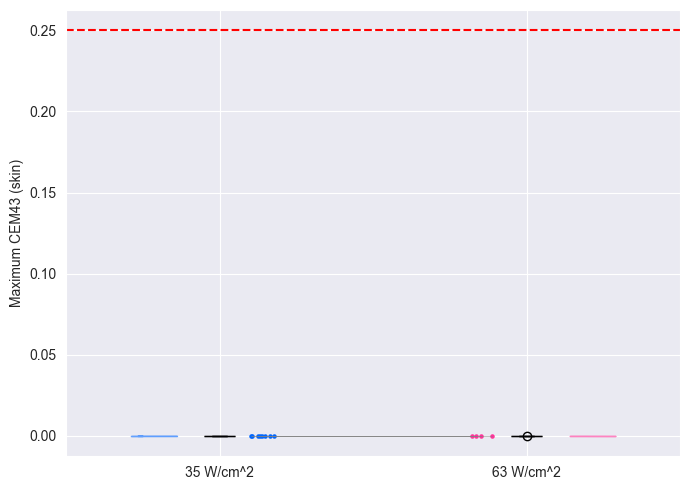

In [12]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_1_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='CEM43_skin',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='35',
        column_2='63',
        labels=['35 W/cm^2', '63 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum CEM43 (skin)',
        plot_name='Maximum CEM43 in skin for amygdala stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

In [13]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_2_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='CEM43_skin',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='63',
        column_2='81',
        labels=['63 W/cm^2', '81 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum CEM43 (skin)',
        plot_name='Maximum CEM43 in skin for dACC stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

    subject_id      target  35        81
0            5  target_2_1 NaN  0.000000
1            5  target_2_2 NaN  0.000084
2            5  target_2_3 NaN  0.000112
3            5  target_2_4 NaN  0.000187
4            5  target_2_5 NaN  0.000213
..         ...         ...  ..       ...
84          44  target_2_2 NaN  0.000088
85          44  target_2_3 NaN  0.000095
86          44  target_2_4 NaN  0.000197
87          44  target_2_5 NaN  0.000227
88          44  target_2_6 NaN  0.000433

[89 rows x 4 columns]
Skipping block due to error: '63'


## Brain

   subject_id      target        35        63
0           5  target_1_1  0.000036  0.000037
1           5  target_1_2  0.000082  0.000086
2          10  target_1_1  0.000036       NaN
3          22  target_1_1  0.000036  0.000037
4          22  target_1_2  0.000081       NaN
5          37  target_1_1  0.000037  0.000039
6          37  target_1_2  0.000083       NaN
7          37  target_1_3  0.000128       NaN


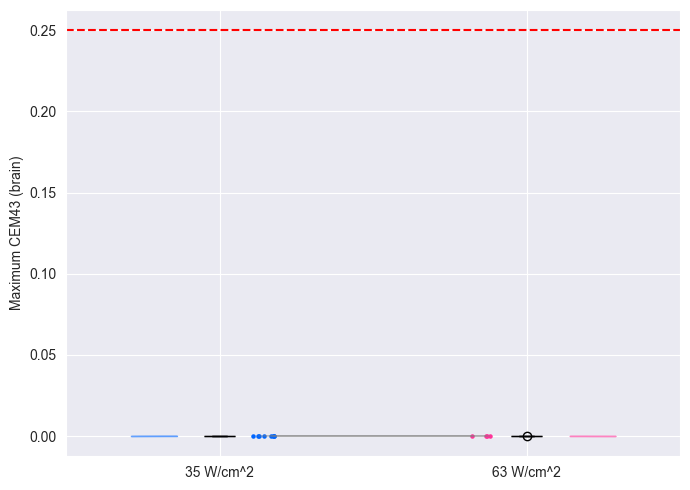

In [14]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_1_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='CEM43_brain',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='35',
        column_2='63',
        labels=['35 W/cm^2', '63 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum CEM43 (brain)',
        plot_name='Maximum CEM43 in brain for amygdala stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

In [15]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_2_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='CEM43_brain',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='63',
        column_2='81',
        labels=['63 W/cm^2', '81 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum CEM43 (brain)',
        plot_name='Maximum CEM43 in brain for dACC stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

    subject_id      target  35        81
0            5  target_2_1 NaN  0.000042
1            5  target_2_2 NaN  0.000093
2            5  target_2_3 NaN  0.000145
3            5  target_2_4 NaN  0.000200
4            5  target_2_5 NaN  0.000269
..         ...         ...  ..       ...
84          44  target_2_2 NaN  0.000095
85          44  target_2_3 NaN  0.000147
86          44  target_2_4 NaN  0.000206
87          44  target_2_5 NaN  0.000280
88          44  target_2_6 NaN  0.000461

[89 rows x 4 columns]
Skipping block due to error: '63'


# Max temperature rise in skin and brain
2 degrees is the safety limit
Group by target and intensity

In [16]:
safety_limit = 39

## Skin

   subject_id      target        35        63
0           5  target_1_1  36.94229  36.94230
1           5  target_1_2  38.30722  38.30722
2          10  target_1_1  36.90619       NaN
3          22  target_1_1  36.89610  36.89611
4          22  target_1_2  38.28725       NaN
5          37  target_1_1  36.93686  36.93689
6          37  target_1_2  38.29320       NaN
7          37  target_1_3  38.29956       NaN


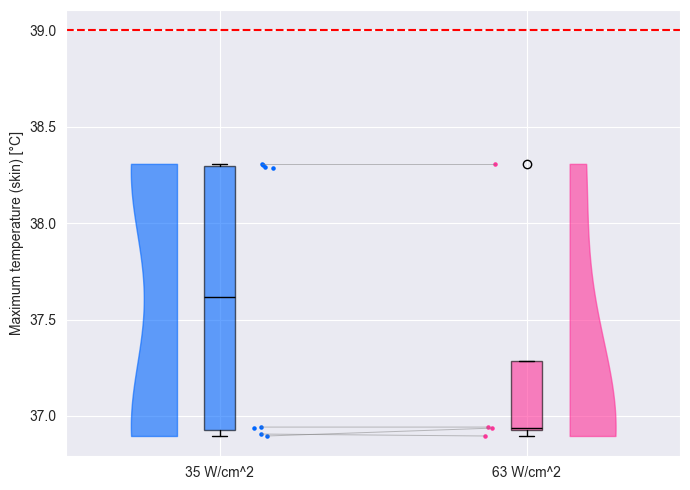

In [17]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_1_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='maxT_skin',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='35',
        column_2='63',
        labels=['35 W/cm^2', '63 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum temperature (skin) [°C]',
        plot_name='Maximum temp in skin for amygdala stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

In [18]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_2_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='maxT_skin',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='63',
        column_2='81',
        labels=['63 W/cm^2', '81 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum temperature (skin) [°C]',
        plot_name='Maximum temp in skin for dACC stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

    subject_id      target  35         81
0            5  target_2_1 NaN  36.896435
1            5  target_2_2 NaN  38.431705
2            5  target_2_3 NaN  38.418870
3            5  target_2_4 NaN  38.421025
4            5  target_2_5 NaN  38.406590
..         ...         ...  ..        ...
84          44  target_2_2 NaN  38.785870
85          44  target_2_3 NaN  38.552950
86          44  target_2_4 NaN  38.588120
87          44  target_2_5 NaN  38.443840
88          44  target_2_6 NaN  38.344360

[89 rows x 4 columns]
Skipping block due to error: '63'


## Brain

   subject_id      target        35        63
0           5  target_1_1  37.07851  37.12492
1           5  target_1_2  37.96815  37.96815
2          10  target_1_1  37.08584       NaN
3          22  target_1_1  37.06983  37.11140
4          22  target_1_2  37.94552       NaN
5          37  target_1_1  37.09899  37.16058
6          37  target_1_2  38.05426       NaN
7          37  target_1_3  37.96391       NaN


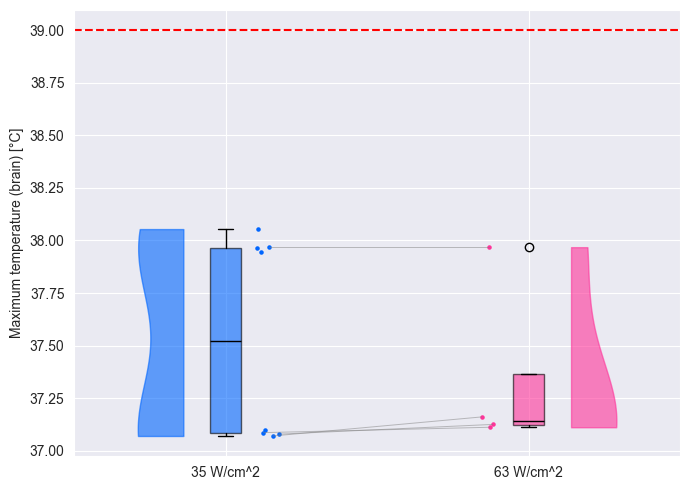

In [19]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_1_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='maxT_brain',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='35',
        column_2='63',
        labels=['35 W/cm^2', '63 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum temperature (brain) [°C]',
        plot_name='Maximum temp in brain for amygdala stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

In [20]:
try:
    # Single out the amygdala targets
    stimulation_output_pivoted = stimulation_output[stimulation_output['target'].str.contains('target_2_')]

    # Single-pass aggregation & reshape
    stimulation_output_pivoted = (
        stimulation_output_pivoted
        .pivot_table(
            index=['subject_id','target'],
            columns='intensity',
            values='maxT_brain',
            aggfunc='mean'
        )
        .reset_index()
    )
    stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)
    print(stimulation_output_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_2_groups(
        stimulation_output_pivoted,
        column_1='63',
        column_2='81',
        labels=['63 W/cm^2', '81 W/cm^2'],
        output_dir=plot_dir,
        ylabel_name='Maximum temperature (brain) [°C]',
        plot_name='Maximum temp in brain for dACC stimulation',
        hline=safety_limit
    )
except Exception as e:
    print(f"Skipping block due to error: {e}")

    subject_id      target  35         81
0            5  target_2_1 NaN  37.054625
1            5  target_2_2 NaN  38.618430
2            5  target_2_3 NaN  38.129815
3            5  target_2_4 NaN  38.758710
4            5  target_2_5 NaN  38.068910
..         ...         ...  ..        ...
84          44  target_2_2 NaN  38.594220
85          44  target_2_3 NaN  38.007040
86          44  target_2_4 NaN  38.855900
87          44  target_2_5 NaN  38.166900
88          44  target_2_6 NaN  38.787590

[89 rows x 4 columns]
Skipping block due to error: '63'
